## 1. Chargement et exploration des données

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
import pandas as pd
import numpy as np
from keras.optimizers import Adam
from sklearn.model_selection import ParameterSampler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
# Charger les données
df = pd.read_csv("data/ENB2012_data.csv")
# Le fichier Excel contient 768 observations et 10 colonnes (8 features + 2 cibles).
# Renommer les colonnes pour plus de clarté
df.columns = [
    "Relative_Compactness",  # X1 – compacité relative du bâtiment
    "Surface_Area",          # X2 – surface totale (m²)
    "Wall_Area",             # X3 – surface des murs extérieurs (m²)
    "Roof_Area",             # X4 – surface du toit (m²)
    "Overall_Height",        # X5 – hauteur totale (m)
    "Orientation",           # X6 – orientation (2,3,4,5 → N,S,E,O)
    "Glazing_Area",          # X7 – surface vitrée (proportion)
    "Glazing_Area_Distrib",  # X8 – répartition des fenêtres
    "Heating_Load",          # Y1 – charge de chauffage  ← CIBLE
    "Cooling_Load"           # Y2 – charge de refroidissement (non utilisée ici)
]

print("Dimensions :", df.shape)
df.head()



Dimensions : (768, 10)


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distrib,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


Le dataset ENB2012 contient 768 observations et 10 colonnes (8 variables explicatives + 2 cibles). On cible uniquement Heating_Load (Y1), la charge de chauffage en kWh/m².


In [3]:
#Statistiques descriptives
df.describe().round(2)

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distrib,Heating_Load,Cooling_Load
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,0.76,671.71,318.50,176.60,5.25,3.50,0.23,2.81,22.31,24.59
std,0.11,88.09,43.63,45.17,1.75,1.12,0.13,1.55,10.09,9.51
min,0.62,514.50,245.00,110.25,3.50,2.00,0.00,0.00,6.01,10.90
25%,0.68,606.38,294.00,140.88,3.50,2.75,0.10,1.75,12.99,15.62
50%,0.75,673.75,318.50,183.75,5.25,3.50,0.25,3.00,18.95,22.08
75%,0.83,741.12,343.00,220.50,7.00,4.25,0.40,4.00,31.67,33.13
max,0.98,808.50,416.50,220.50,7.00,5.00,0.40,5.00,43.10,48.03


La variable cible Heating_Load varie entre 6.01 et 43.10 kWh/m², avec une moyenne de 22.31 et un écart-type de 10.09, indiquant une grande variabilité entre les bâtiments.

In [4]:
# Vérification des valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())


Valeurs manquantes par colonne :
Relative_Compactness    0
Surface_Area            0
Wall_Area               0
Roof_Area               0
Overall_Height          0
Orientation             0
Glazing_Area            0
Glazing_Area_Distrib    0
Heating_Load            0
Cooling_Load            0
dtype: int64


Aucune valeur manquante → aucun prétraitement supplémentaire nécessaire. 

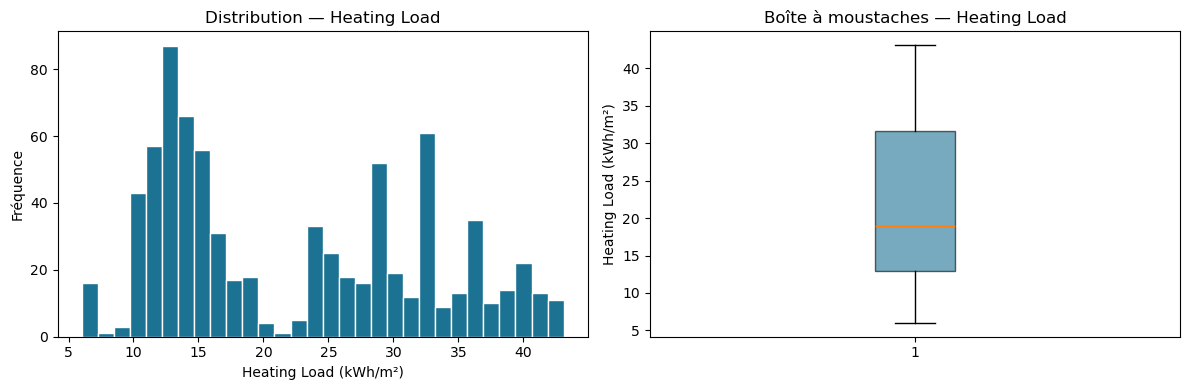

In [5]:
# ─── Distribution de la variable cible ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Heating_Load"], bins=30, color="#1C7293", edgecolor="white")
axes[0].set_title("Distribution — Heating Load")
axes[0].set_xlabel("Heating Load (kWh/m²)")
axes[0].set_ylabel("Fréquence")

axes[1].boxplot(df["Heating_Load"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="#1C7293", alpha=0.6))
axes[1].set_title("Boîte à moustaches — Heating Load")
axes[1].set_ylabel("Heating Load (kWh/m²)")

plt.tight_layout()
plt.savefig('distribution heating load.png', dpi=300, bbox_inches='tight')
plt.show()

Histogramme — Distribution
La distribution est bimodale → il y a deux pics distincts, un autour de ~13 et un autre autour de ~33
Cela suggère que les bâtiments se divisent en deux groupes : les peu énergivores et les très énergivores
La distribution n'est pas normale → pas de cloche symétrique.

Cette distribution bimodale justifie l'utilisation d'un réseau de neurones plutôt qu'une régression linéaire simple, car le modèle doit capturer cette structure complexe à deux groupes.

Boîte à moustaches:
Médiane autour de ~19 kWh/m²
50% des valeurs se situent entre ~13 et ~31 (l'interquartile)
Pas d'outliers visibles → les moustaches s'étendent de ~5 à ~42
L'écart est assez large → grande variabilité dans les données

## 2. Prétraitement des données

In [6]:
#Séparation des features et de la cible
# On conserve uniquement Y1 (Heating Load) comme variable cible.
X = df.drop(columns=["Heating_Load", "Cooling_Load"])
y = df["Heating_Load"]

On conserve les 8 variables explicatives (X1 à X8) comme features d'entrée, et on isole Heating_Load comme variable cible (Y). La colonne Cooling_Load est également exclue car on ne la prédit pas ici.

In [7]:
#Découpage Train / Test
x_train, x_test, y_train, y_test=train_test_split(X,y, test_size=0.2,random_state=42)

Le dataset est divisé en 80% entraînement (614 observations) et 20% test (154 observations). Le paramètre random_state=42 garantit la reproductibilité des résultats.



In [8]:
# Normalisation 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

La normalisation centre chaque feature à moyenne = 0 et écart-type = 1. C'est essentiel pour les réseaux de neurones, car des features à échelles très différentes (ex: Surface_Area ~500-800 vs Glazing_Area ~0-0.4) peuvent ralentir ou déstabiliser l'apprentissage.

## 3. Construction du modèle

In [9]:
model=Sequential([
Input(shape=(x_train.shape[1],),name="Input_Layer"), #couche d'entré
Dense(64,activation="relu", name="Hidden_Layer_1"),
Dense(32,activation="relu", name="Hidden_Layer_2"),
Dense(1,activation="linear", name="Output_Layer")]) # Regression

#Compilation du modele
model.compile(loss='mean_squared_error', optimizer='adam',metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)               │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_Layer_2 (Dense)               │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output_Layer (Dense)                 │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

Nous avons choisi un modèle de réseau de neurones de type séquentiel, composé de 4 couches:

| Couche | Neurones | Activation | Rôle |
|--------|----------|------------|------|
| Input | 8 | — | Reçoit les 8 features |
| Hidden 1 | 64 | ReLU | Apprentissage des patterns complexes |
| Hidden 2 | 32 | ReLU | Raffinage des représentations |
| Output | 1 | Linéaire | Prédit une valeur continue (régression) |

In [10]:
#Entrainement du modele
history=model.fit(x_train, y_train, validation_split=0.2, epochs=100)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 604.2313 - mae: 22.2719 - val_loss: 525.8168 - val_mae: 20.7003
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 565.7009 - mae: 21.2805 - val_loss: 484.5720 - val_mae: 19.5668
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 518.1181 - mae: 19.9817 - val_loss: 428.3516 - val_mae: 17.9790
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 450.5008 - mae: 18.1153 - val_loss: 353.2217 - val_mae: 15.7402
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 360.2212 - mae: 15.5405 - val_loss: 260.5094 - val_mae: 12.7800
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 253.4127 - mae: 12.2341 - val_loss: 159.6803 - val_mae: 9.2958
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 144.5155 - mae: 8.7232 - val_loss: 80.3203 - val_mae: 6.1599
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 68.2500 - mae: 5.7794 - val_loss: 40.3130 - val_mae: 4.4424
Epoch 9/100
16/1

Le modèle est entraîné sur 100 époques avec un validation_split=0.2, ce qui signifie que 20% des données d'entraînement sont automatiquement réservées pour surveiller la progression du modèle à chaque époque, sans participer à l'apprentissage.

À l'époque 1, la MAE démarre très haute (~22 kWh/m²), ce qui est normal — le modèle n'a pas encore appris. Elle chute rapidement jusqu'à l'époque ~10, puis continue de diminuer progressivement jusqu'à converger autour de ~1.36 kWh/m² à l'époque 100.

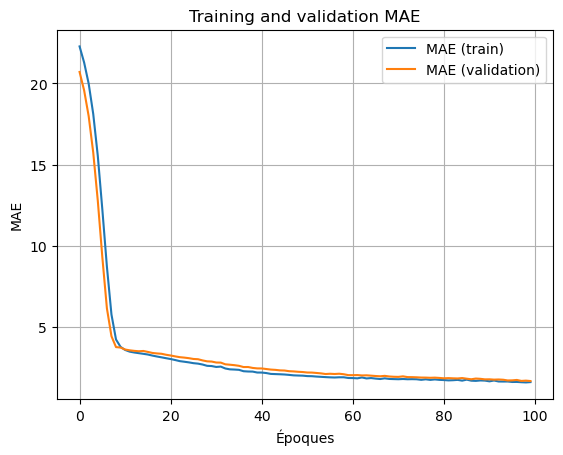

In [11]:
import matplotlib.pyplot as plt

# Tracé  (MAE) pour l'entraînement
plt.plot(history.history['mae'], label='MAE (train)')

# Tracé (MAE) pour la validation
plt.plot(history.history['val_mae'], label='MAE (validation)')
plt.title("Training and validation MAE")
plt.xlabel("Époques")
plt.ylabel("MAE")

# Ajout de la légende, de la grille et affichage
plt.legend()
plt.grid(True)

plt.savefig('courbe_apprentissage.png', dpi=300, bbox_inches='tight')
plt.show()

3 phases visibles sur la courbe :
Phase 1 — Descente rapide (époques 1–10) :

La MAE chute drastiquement de ~22 à ~4. Le modèle apprend très vite les relations principales entre les features et le Heating Load.

Phase 2 — Descente progressive (époques 10–60) :

La courbe continue de descendre mais plus lentement. Le modèle affine ses poids pour capturer des patterns plus subtils.

Phase 3 — Convergence (époques 60–100) :

Les deux courbes (train et validation) se stabilisent et restent proches l'une de l'autre — signe que le modèle généralise bien sans overfitting.

In [12]:
#Evaluation du modele
loss,mae=model.evaluate(x_test, y_test)
print(f"Mean squared error (MSE):{loss}")
print(f"Mean Absolute error (MAE):{mae}")
from sklearn.metrics import r2_score
y_pred = model.predict(x_test)
print(f"R² : {r2_score(y_test, y_pred)}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.7729 - mae: 1.7354
Mean squared error (MSE):5.772933006286621
Mean Absolute error (MAE):1.73539400100708
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
R² : 0.9446143385230151


Le modèle est évalué sur le jeu de test (20% des données, jamais vus pendant l'entraînement).

| Métrique | Valeur | Interprétation |
|----------|--------|----------------|
| **MSE**  | 5.77   | Erreur quadratique moyenne |
| **MAE**  | 1.73 kWh/m² | Erreur moyenne absolue |
| **R²**   | 0.944  | 94.4% de la variance expliquée |

Le modèle se trompe en moyenne de **±1.73 kWh/m²**, ce qui est satisfaisant
compte tenu de la plage de valeurs (6 à 43 kWh/m²).

Le **R² de 0.944** confirme que le modèle capture très bien la relation
entre les caractéristiques du bâtiment et sa charge de chauffage.
Les courbes train/validation proches indiquent l'absence d'overfitting.

## 4. Optimisation des hyperparamètres — Random Search

In [16]:
from sklearn.model_selection import ParameterSampler
from keras.optimizers import Adam

param_grid = {
    "neurons": [(32,16), (64,32), (128, 64)],
    "epochs": [50, 100, 150],
    "batch_size": [16, 32, 64],
    "lr": [0.001, 0.01, 0.0005]
}
# On définit le nombre de combinaisons à tester 
n_iteration = 20 
random_combinations = ParameterSampler(param_grid, n_iter=n_iteration, random_state=42)
results_list = []
for params in random_combinations:
    h1, h2 = params["neurons"]
    model = Sequential([
        Input(shape=(x_train.shape[1],)),
        Dense(h1, activation="relu"),
        Dense(h2, activation="relu"),
        Dense(1, activation="linear")
    ])
    model.compile(optimizer=Adam(learning_rate=params["lr"]), loss="mse")
    
    history=model.fit(x_train, y_train,validation_split=0.2, epochs=params["epochs"], 
              batch_size=params["batch_size"], verbose=0)
 
    val_loss = min(history.history['val_loss'])
    res = params.copy()
    res["loss"] = val_loss
    results_list.append(res)

# Affichage des meilleurs résultats
df_results = pd.DataFrame(results_list)
print(df_results.sort_values(by="loss").head())

    neurons     lr  epochs  batch_size      loss
2  (64, 32)  0.010     150          16  0.201548
9  (32, 16)  0.010     100          16  0.346783
8  (64, 32)  0.010      50          16  2.420070
4  (32, 16)  0.001     150          16  2.426664
3  (64, 32)  0.010      50          32  3.333287


Le Random Search teste **20 combinaisons aléatoires** parmi les hyperparamètres suivants :
- Neurones : (32,16), (64,32), (128,64)
- Learning rate : 0.0005, 0.001, 0.01
- Epochs : 50, 100, 150
- Batch size : 16, 32, 64

| Neurons | LR    | Epochs | Batch size | Val Loss |
|---------|-------|--------|------------|----------|
| (64,32) | 0.010 | 150    | 16         | **0.20** ✅ |
| (32,16) | 0.010 | 100     | 16         | 0.34     |
| (64,32) | 0.010 | 50    | 16         | 2.420     |
| (32,16) | 0.001 | 150    | 16         | 2.426     |
| (64,32) | 0.010 | 50     | 32         | 3.33     |

**Observations :**
- Le **learning rate = 0.01** domine le top des résultats → paramètre le plus influent
- Le **batch_size = 16** est systématiquement présent dans les meilleures combinaisons
- Plus le nombre d'**epochs est élevé**, meilleur est le résultat

La meilleure combinaison retenue est :
**neurons=(64,32), lr=0.01, epochs=150, batch_size=16**

## 5. Modèle final — Analyse et interprétation

In [63]:
best_model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="linear")
])

best_model.compile(
    optimizer=Adam(learning_rate=0.01), 
    loss="mse", 
    metrics=["mae"] 
)

best_model.fit(x_train, y_train, epochs=150, batch_size=16, verbose=0)
best_model.summary()
loss, mae = best_model.evaluate(x_test, y_test)
print(f"MSE: {loss}")
print(f"MAE: {mae}")
y_pred = best_model.predict(x_test)
print(f"R² : {r2_score(y_test, y_pred)}")


Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_81 (Dense)                     │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_82 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_83 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,069 (31.52 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,380 (21.02 KB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2411 - mae: 0.3681  
MSE: 0.24109922349452972
MAE: 0.36811143159866333
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
R² : 0.9976868874993806


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


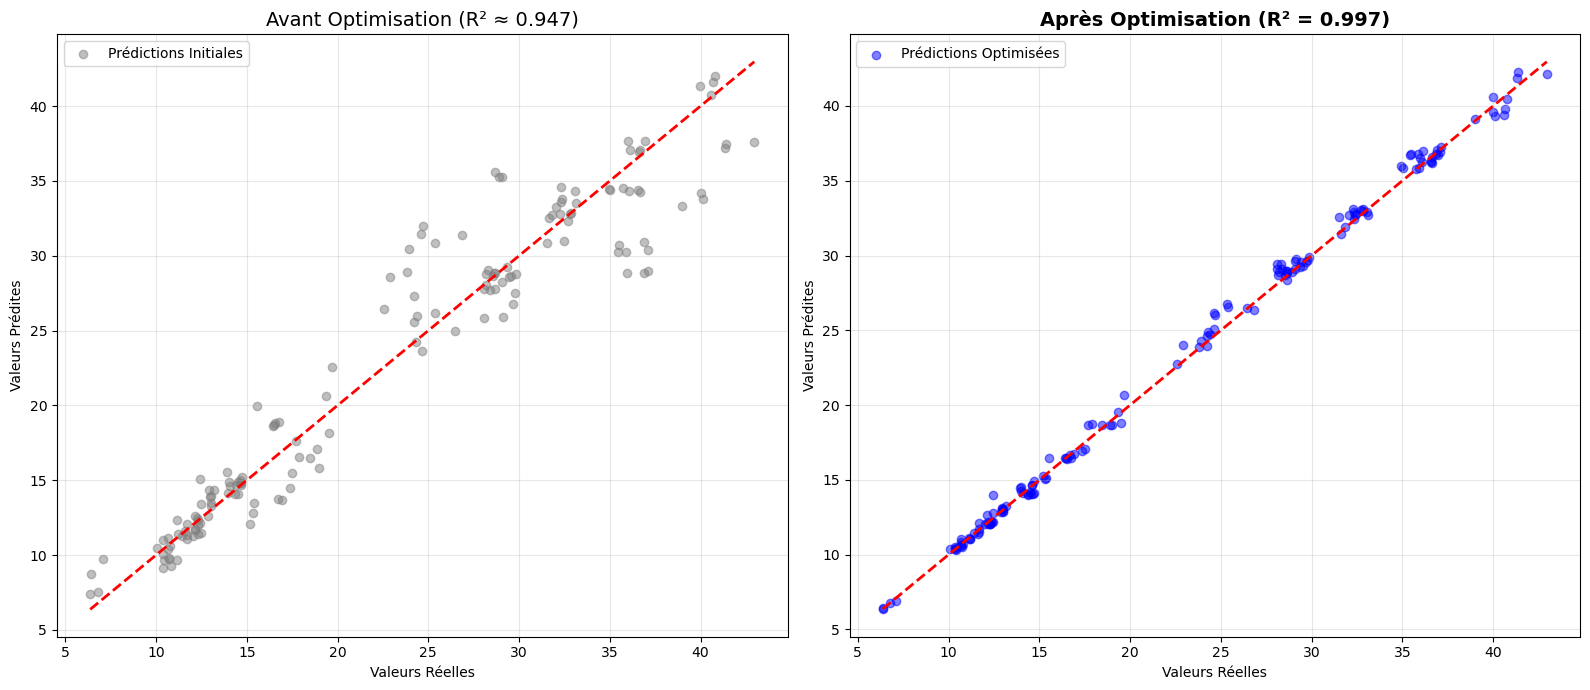

In [60]:
import matplotlib.pyplot as plt

# Supposons que 'model_initial' est votre premier modèle 
# et 'model' (ou 'model_final') est votre modèle après Random Search.

# 1. Génération des prédictions
y_pred_initial = model.predict(x_test)
y_pred_final = best_model.predict(x_test)

# 2. Création de la figure avec 2 sous-graphiques (côte à côte)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- GRAPHIQUE 1 : AVANT OPTIMISATION ---
ax1.scatter(y_test, y_pred_initial, alpha=0.5, color='gray', label='Prédictions Initiales')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_title('Avant Optimisation (R² ≈ 0.947)', fontsize=14)
ax1.set_xlabel('Valeurs Réelles')
ax1.set_ylabel('Valeurs Prédites')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- GRAPHIQUE 2 : APRÈS OPTIMISATION ---
ax2.scatter(y_test, y_pred_final, alpha=0.5, color='blue', label='Prédictions Optimisées')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_title('Après Optimisation (R² = 0.997)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Valeurs Réelles')
ax2.set_ylabel('Valeurs Prédites')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# 3. SAUVEGARDE
plt.savefig('comparatif_avant_apres.png', dpi=300, bbox_inches='tight')
plt.show()

Le modèle final est entraîné avec les hyperparamètres optimaux issus du Random Search.

| Métrique | Modèle initial | Modèle optimisé | Amélioration |
|----------|---------------|-----------------|--------------|
| **MSE**  | 5.39          | **0.24**        | -95.5%✅ |
| **MAE**  | 1.79 kWh/m²   | **0.36 kWh/m²** | -79.9%✅ |
| **R²**   | 0.947         | **0.997**       | +5.3% ✅ |

### Conclusion

Le modèle optimisé atteint un **R² de 0.997**, ce qui signifie qu'il explique
**99.7% de la variance** de la charge de chauffage des bâtiments.

Avec une erreur moyenne de seulement **±0.36 kWh/m²** sur une plage de 6 à 43 kWh/m²,
le modèle est capable de prédire avec une très grande précision la consommation
énergétique d'un bâtiment à partir de ses caractéristiques physiques.

Le Random Search a permis de réduire significativement l’erreur (jusqu’à ~95% selon la métrique MSE)par rapport au modèle initial,
confirmant l'importance de l'optimisation des hyperparamètres dans la construction d'un réseau de neurones performant.